# Customer Churn Prediction

## Business Problem
A telecom company wants to identify customers likely to churn so that retention teams can proactively engage them.

## Objective
Build an end-to-end machine learning model to predict customer churn.

In [5]:
# Importing the required libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
%matplotlib inline

In [6]:
import sys
print(sys.executable)

c:\Users\jasmeetkaur02\Documents\NAGP\data-science\.venv\Scripts\python.exe


In [7]:
# Importing required packages for visualization
from IPython.display import Image  
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus, graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

## Data Understanding & Preparation

### Data Understanding

#### Data Loading

In [8]:
# Reading the csv file and putting it into 'df' object.
df = pd.read_csv("../data/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [101]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [102]:
df.shape


(7043, 21)

#### Data Types

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Summary Statistics

In [53]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Numerical and categorical feature identification

In [54]:
#Check numeric columns
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [55]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [56]:
# Check categorical columns
df.select_dtypes(exclude=np.number).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

#### Important Observations

- Dataset contains 7,043 records and 21 columns.
- Three numerical features were identified initially.
- Rest of the features are categorical/non-numerical.
- customerID acts as an identifier.

### Missing Value Analysis

#### Check missing values

In [57]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Check blanks

In [58]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

#### Observation

- Missing values were found in the **`TotalCharges`** column.  
- These occur because some customers have a **tenure of 0 months** — they are new customers who have not yet been billed. As a result, their total charges are unavailable and appear as blank values in the dataset.  
- The dataset contains **11 missing values** in `TotalCharges`.  
- These corresponded exclusively to customers with **tenure = 0**.  


### Duplicate Analysis

In [59]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

#### Observation

No duplicate records were found in the dataset.

### Target variable analysis

In [60]:
# Check the target variable distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [61]:
# Check the target variable distribution in percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Observation

Approximately 26.5% of customers churned,
while 73.5% remained with the company.

### Data Cleaning

#### Fix TotalCharges data type

     The TotalCharges column was initially read as an object due to blank values.Converted to numeric.


#### Drop unnecessary columns

In [9]:
# Data Preprocessing - Drop customerID column
df.drop("customerID", axis=1, inplace=True)

#### Handle Missing Values

In [10]:
# Convert TotalCharges to numeric, coercing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
# Check for any remaining missing values in the dataset
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [12]:
#Check numeric columns
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

##### Observation

- The dataset now contains **four numerical features** (`tenure`, `MonthlyCharges`, `TotalCharges`, and `SeniorCitizen`), with the remaining variables categorical.  



## Exploratory Data Analysis

### Chart 1: Churn Distribution

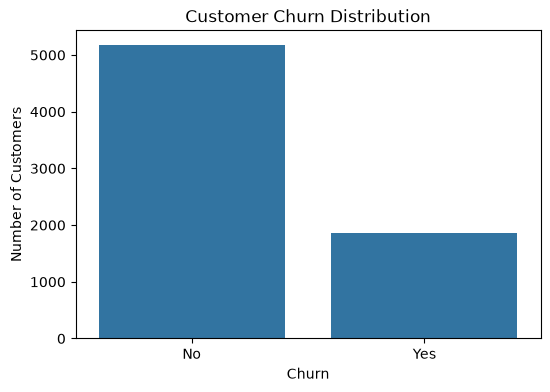

In [13]:
# Visualize the target variable distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


#### Business Insight:

The majority of customers have been retained, while a significant proportion have churned.
Customer attrition remains a key business concern as it directly impacts recurring revenue and customer lifetime value.
Retention strategies should focus on identifying and engaging customers at risk of leaving.

### Chart 2: Contract vs Churn

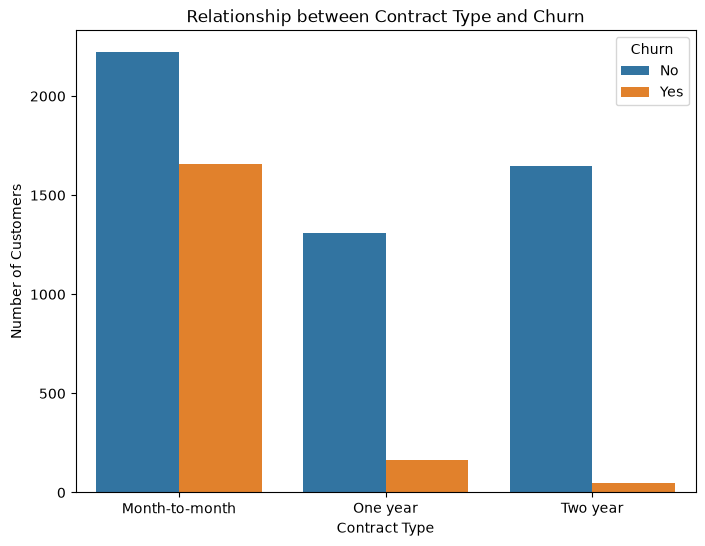

In [68]:
# Visualize the relationship between Contract type and Churn
plt.figure(figsize=(8,6))
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.title("Relationship between Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

#### Business Insight:

Customers with month-to-month contracts show the highest churn rates.
Customers on one-year and two-year contracts are more likely to stay with the company.
Promoting long-term contracts through discounts and loyalty benefits could help reduce churn.

### Chart 3: Tenure vs Churn

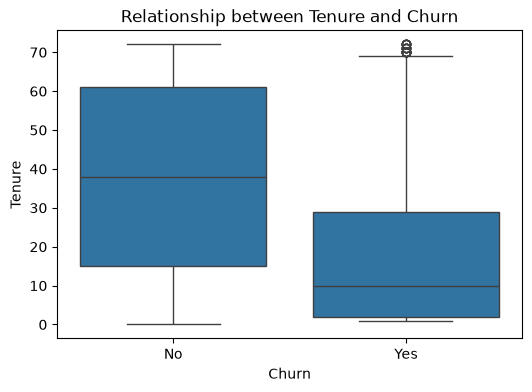

In [69]:
# Visualize the relationship between tenure and Churn
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.title("Relationship between Tenure and Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

#### Business Insight:

Churned customers generally have lower tenure than retained customers.
New customers are more likely to leave, while long-term customers tend to be more loyal.
Improving onboarding and early customer engagement may help reduce churn among newer customers.

### Chart 4: MonthlyCharges vs Churn

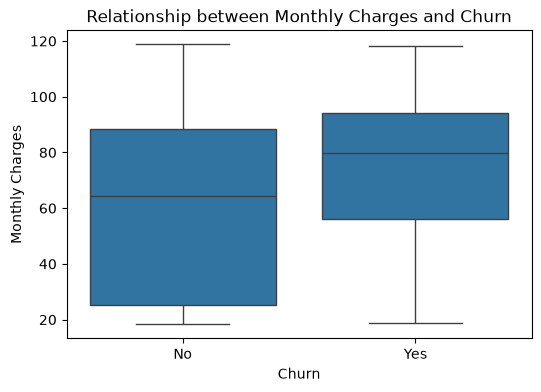

In [70]:
# Visualize the relationship between Monthly Charges and Churn
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)
plt.title("Relationship between Monthly Charges and Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Business Insight:

Customers who churn tend to have higher monthly charges on average.
Higher service costs may increase customer dissatisfaction or encourage customers to switch to competitors.
The company should evaluate pricing strategies and ensure high-value plans deliver sufficient benefits.

### Chart 5: InternetService vs Churn

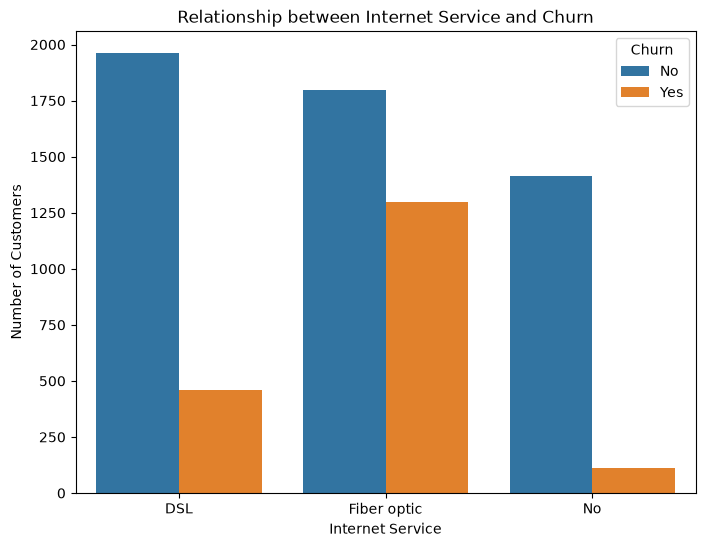

In [71]:
# Visualize the relationship between Internet Service and Churn
plt.figure(figsize=(8,6))
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)
plt.title("Relationship between Internet Service and Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

#### Business Insight:

Customers using Fiber Optic internet services exhibit higher churn rates compared to DSL customers.
This may indicate concerns related to pricing, service quality, or customer expectations within the Fiber Optic segment.
Further investigation into Fiber Optic customer satisfaction could help identify opportunities to improve retention.



### Chart 6 : Payment method vs Churn

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

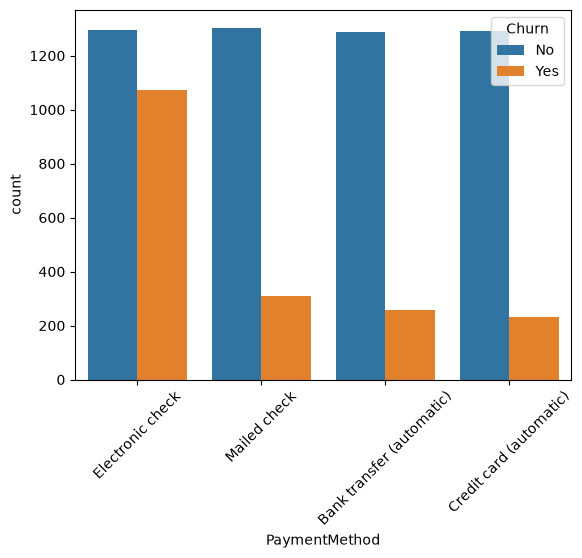

In [72]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

#### Business Insight

This suggests that customers who opt for automatic payment methods are more stable and loyal, while manual or electronic check users may be less committed and more likely to leave.

### Overall Conclusion

The analysis indicates that churn is strongly associated with short customer tenure, month‑to‑month contracts, higher monthly charges, and Fiber Optic internet service. Customers on long‑term contracts and those with longer tenure demonstrate greater loyalty.

Additionally, churn is significantly higher among customers using Electronic Check as their payment method, while those opting for automatic payments (Credit Card or Bank Transfer) show greater stability.

Therefore, customer retention efforts should focus on:

New customers with low tenure, ensuring strong onboarding and early engagement.

High‑billing customers, by reviewing pricing strategies and delivering clear value.

Month‑to‑month contract subscribers, by promoting long‑term plans with incentives.

Electronic Check users, by encouraging a shift to automatic payment methods through discounts or loyalty rewards.

## Feature Engineering

### Feature Name: ServiceCount

Creation Method: Counted the number of value-added services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) subscribed to by each customer.

Business Rationale: Customers using more services are generally more integrated into the company's ecosystem and may have a lower likelihood of churning. This feature captures customer engagement in a single variable and can improve churn prediction.

### Feature Name: AvgMonthlySpend

Creation Method: Calculated as TotalCharges divided by tenure.

Business Rationale: Represents customer spending behavior.

In [15]:
df["AvgMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

## Train Test Split
70:30 split as required
random_state=42 for reproducibility

### Prepare X and Y

In [16]:
# Prepare the features and target variable for modeling

# Convert target to numeric BEFORE splitting
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop("Churn", axis=1)

y = df["Churn"]
X
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

### Split

In [17]:
# Split the dataset into training and testing sets
# 70:30 split with random_state=42 used for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
print("TRAIN X SHAPE:",X_train.shape)
print("TRAIN Y SHAPE:",y_train.shape)
print("VALUE COUNTS:\n",y_train.value_counts())
print("TEST X SHAPE :",X_test.shape)
print("TEST Y SHAPE :",y_test.shape)

TRAIN X SHAPE: (4930, 21)
TRAIN Y SHAPE: (4930,)
VALUE COUNTS:
 Churn
0    3635
1    1295
Name: count, dtype: int64
TEST X SHAPE : (2113, 21)
TEST Y SHAPE : (2113,)


## Data Preprocessing

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Convert the target variable to numeric so that the target value is not renamed 
# during one-hot encoding
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})


num_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "AvgMonthlySpend", "ServiceCount"]
cat_features = [col for col in X_train.columns if col not in num_features]

# Define transformers
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# Fit on training data
X_train_final = preprocessor.fit_transform(X_train)
X_test_final  = preprocessor.transform(X_test)


In [24]:
# Check NaNs after conversion
print("NaNs in X_train after imputation:", np.isnan(X_train_final).sum())
print("NaNs in X_test after imputation:", np.isnan(X_test_final).sum())

# Check the categories of the one-hot encoded features
print(preprocessor.named_transformers_['cat'].named_steps['encoder'].categories_)

NaNs in X_train after imputation: 0
NaNs in X_test after imputation: 0
[array(['Female', 'Male'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'No phone service', 'Yes'], dtype=object), array(['DSL', 'Fiber optic', 'No'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['Month-to-month', 'One year', 'Two year'], dtype=object), array(['No', 'Yes'], dtype=object), array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)]


#### Observations
- Before imputation, the dataset contained **11 missing values** in `TotalCharges`.  
- Median imputation was chosen because:  
  - `TotalCharges` is a numerical feature.  
  - Its distribution is **right‑skewed**, with some customers having very high charges.  
  - The **median** is less affected by outliers than the mean, making it a more robust measure of central tendency.  
  - This approach preserves the overall distribution while retaining all records for analysis and model training.  
- After applying median imputation, **all missing values were replaced**, resulting in a dataset with **7,043 complete records** and no nulls.  

## Model Development

In [25]:
print("Final Train Shape:", X_train_final.shape)
print("Final Test Shape:", X_test_final.shape)


Final Train Shape: (4930, 32)
Final Test Shape: (2113, 32)


#### Model 1: Baseline Decision Tree

**Description:**  
A baseline Decision Tree Classifier with a maximum depth of 3.  
This shallow tree is chosen to keep the model simple, interpretable, and less prone to overfitting.

**Key Hyperparameter:**  
- **max_depth = 3**

**Reproducibility Setting:**  
- **random_state = 42**  
  (used to ensure consistent results across runs, but does not affect the model’s learning capacity)


In [26]:
# Model 1

dt1 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt1.fit(X_train_final, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

#### Model 2: Tuned Decision Tree

**Description:**  
A more complex Decision Tree Classifier with a maximum depth of 6 and a minimum sample split requirement of 10.  
This configuration is designed to capture more complex customer churn patterns while reducing the risk of overfitting by preventing splits on very small groups of observations.

**Key Hyperparameters:**  
- **max_depth = 6**
  - Allows the tree to grow deeper and learn more detailed decision rules.
- **min_samples_split = 10**
  - Requires at least 10 samples in a node before it can be split, helping to avoid creating overly specific branches.

**Reproducibility Setting:**  
- **random_state = 42**
  - Ensures consistent and reproducible results across runs.

**Purpose of Comparison:**  
This model is compared against the baseline model to determine whether increased tree complexity improves churn prediction performance. Evaluation metrics such as Accuracy, Precision, Recall, and F1 Score will be used to select the final model.

In [27]:
# Model 2

dt2 = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

dt2.fit(X_train_final, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples i

## Evaluating model performance

Creating helper functions to evaluate model performance and help plot the decision tree

In [32]:
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus

def get_dt_graph(dt_classifier):
    """
    Generate a pydotplus graph object for a trained DecisionTreeClassifier.

    Parameters:
    dt_classifier : DecisionTreeClassifier
        A trained decision tree model.
    preprocessor : ColumnTransformer
        The fitted preprocessing pipeline.
    num_features : list
        List of numerical feature names.
    cat_features : list
        List of categorical feature names.

    Returns:
    graph : pydotplus.graphviz.Dot
        Graphviz representation of the decision tree.
    """
    # Get feature names from both numeric and categorical transformers
    num_names = num_features
    cat_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features).tolist()
    feature_names = num_names + cat_names

    dot_data = StringIO()
    export_graphviz(
        dt_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=feature_names,
        class_names=['No', 'Yes'],
        special_characters=True
    )
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph


In [33]:
def evaluate_model(model):
    pred = model.predict(X_test_final)
    print("Accuracy:", accuracy_score(y_test,pred), flush=True)
    print("Precision:",
          precision_score(y_test,pred))
    print("Recall:",
          recall_score(y_test,pred))
    print("F1:",
          f1_score(y_test,pred))
    print(confusion_matrix(
          y_test,pred))

### Model 1 Evaluation

In [34]:
evaluate_model(dt1)

Accuracy: 0.7813535257927118
Precision: 0.6985815602836879
Recall: 0.343205574912892
F1: 0.4602803738317757
[[1454   85]
 [ 377  197]]


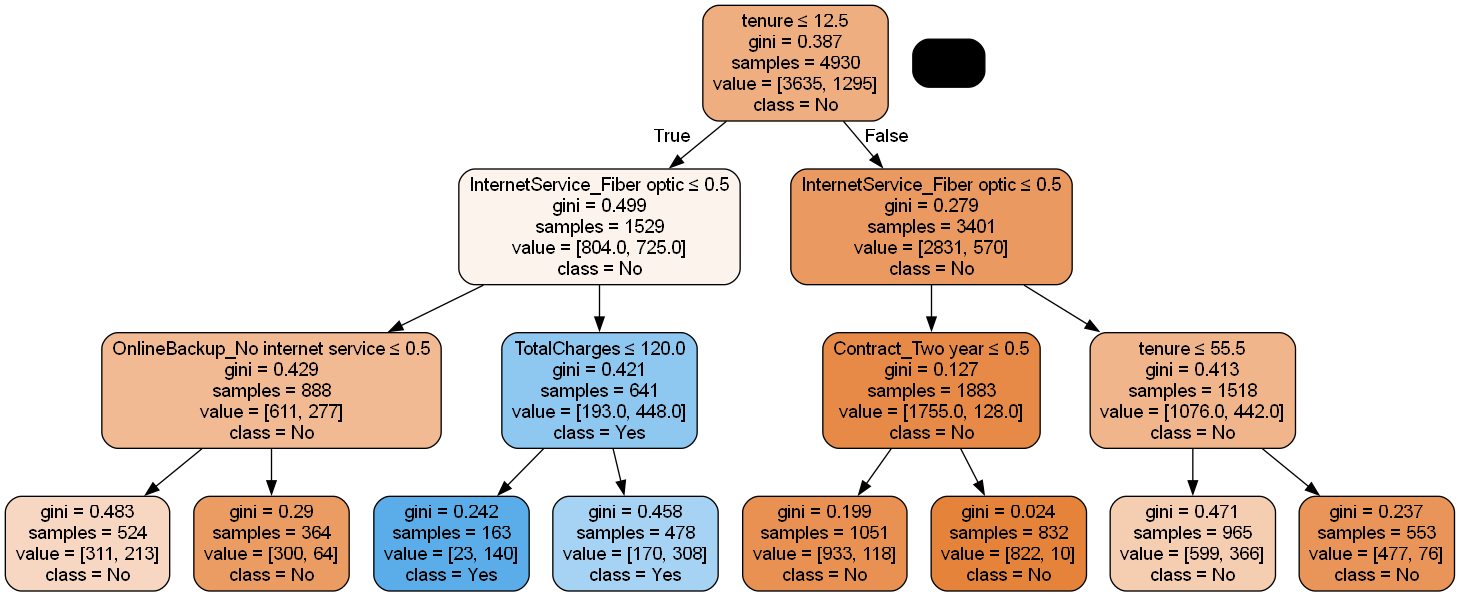

In [35]:
gph = get_dt_graph(dt1)
Image(gph.create_png())


#### Business Interpretation
Accuracy (78.1%) → The model correctly predicts churn vs. non‑churn for most customers. But accuracy alone can be misleading because the dataset is imbalanced (only ~26% churn).

Precision (69.9%) → When the model flags a customer as “likely to churn,” it’s right about 70% of the time. This means retention teams won’t waste too many resources chasing false alarms.

Recall (34.3%) → The model only identifies about one‑third of actual churners. In practice, this means many customers who are at risk of leaving will slip through unnoticed.

F1 Score (46.0%) → Shows the balance between precision and recall. Here, the balance is weak because recall is low.

Confusion Matrix →

1454 True Negatives: Customers correctly predicted to stay.

85 False Positives: Customers predicted to churn but actually stayed (extra retention effort wasted).

377 False Negatives: Customers predicted to stay but actually churned (lost customers not flagged).

197 True Positives: Customers correctly predicted to churn (retention team can act).

### Model 2 Evaluation

In [36]:
evaluate_model(dt2)

Accuracy: 0.7865593942262187
Precision: 0.6289308176100629
Recall: 0.5226480836236934
F1: 0.570884871550904
[[1362  177]
 [ 274  300]]


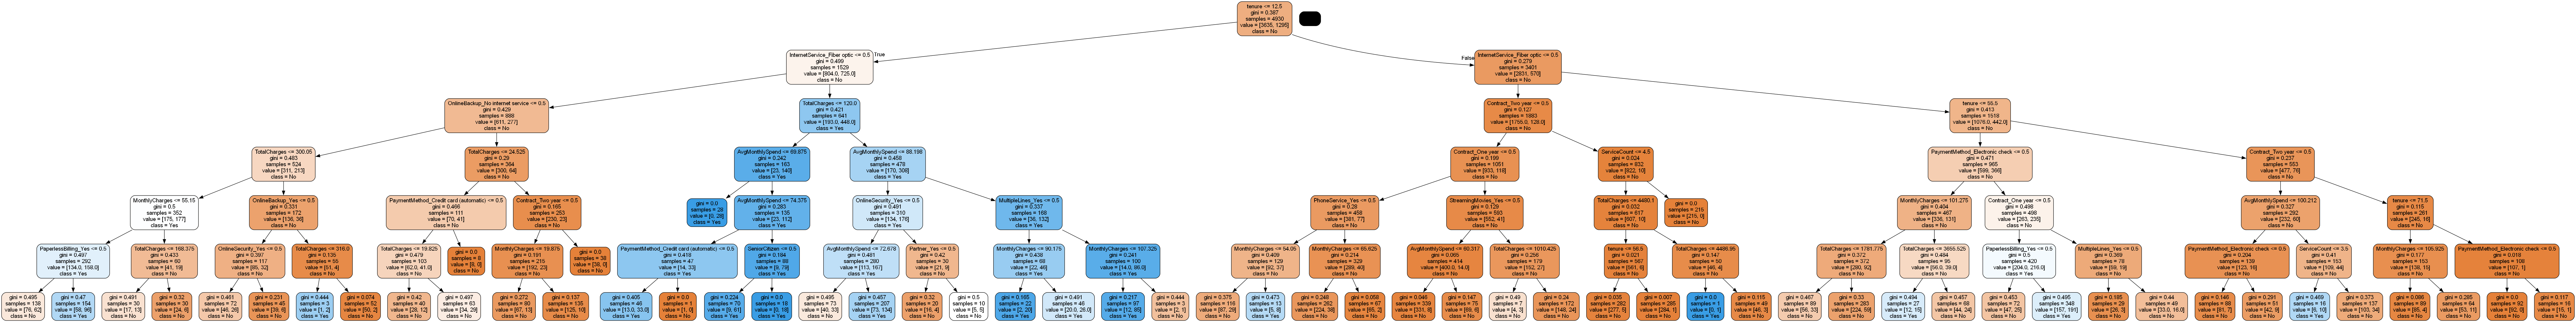

In [132]:
gph = get_dt_graph(dt2)
Image(gph.create_png())


#### Business Interpretation

Accuracy (78.7%) → The model correctly predicts churn vs. non‑churn for nearly 4 out of 5 customers.

Precision (62.9%) → When the model flags a customer as “likely to churn,” it’s right about 63% of the time. This means some false alarms, but most flagged customers are genuinely at risk.

Recall (52.3%) → The model successfully identifies over half of actual churners. This is a big improvement compared to Model 1 (which only caught ~34%).

F1 Score (57.1%) → Shows a better balance between precision and recall, making the model more practical for real‑world use.

1362 True Negatives → Customers correctly predicted to stay.

177 False Positives → Customers predicted to churn but actually stayed (extra retention effort wasted).

274 False Negatives → Customers predicted to stay but actually churned (lost customers not flagged).

300 True Positives → Customers correctly predicted to churn (retention team can act).

### Model Comparison

| **Metric** | **Model 1** | **Model 2** | **Notes** |
| --- | --- | --- | --- |
| **Accuracy** | 78.1% | 78.7% | Nearly identical overall correctness |
| **Precision** | 69.9% | 62.9% | Model 1 avoids false positives better |
| **Recall** | 34.3% | 52.3% | Model 2 catches far more actual churners |
| **F1 Score** | 46.0% | 57.1% | Model 2 achieves better balance |

Compared to Model 1, Model 2 catches far more churners (higher recall), which is critical for a telecom company.

While precision dropped slightly, the trade‑off is acceptable: retention teams may reach out to some customers who would have stayed anyway, but they will also save many more customers who were truly at risk.

The higher F1 score confirms that Model 2 is better balanced and more effective overall.

### For a telecom company, recall is more critical than precision. Here’s why:

If you prioritize precision: You’ll only act on churn predictions that are highly reliable. This avoids wasting retention resources, but you’ll miss many actual churners (like the 377 false negatives here).

If you prioritize recall: You’ll catch more of the customers who are truly at risk of leaving, even if it means some false alarms. In churn prevention, missing a churner is more costly than mistakenly targeting a loyal customer with an offer.

👉 Business takeaway: In customer churn prediction, recall should be prioritized. It’s better to flag more potential churners (even with some false positives) so retention teams can intervene early. Losing a customer is far more expensive than offering a discount or incentive to someone who would have stayed anyway.

## Model Interpretation

### Feature Importance

#### Feature Importance Bar Chart

Length of feature_names: 32
Length of importances: 32


C:\Users\jasmeetkaur02\AppData\Local\Temp\ipykernel_36080\3769934591.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


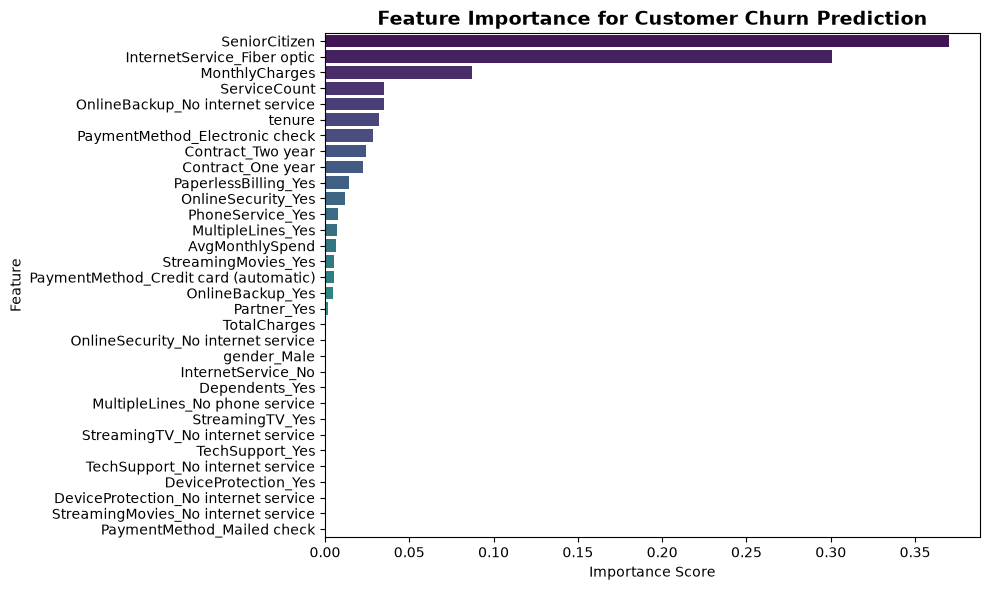

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If you used one-hot encoding, make sure to pass the transformed feature names
# For example, if you used pd.get_dummies:
X_encoded = pd.get_dummies(X, drop_first=True)

# Now feature names must match the model input
feature_names = X_encoded.columns

# Extract feature importances from your trained decision tree
importances = dt2.feature_importances_

# Check lengths to confirm they match
print("Length of feature_names:", len(feature_names))
print("Length of importances:", len(importances))

# Create DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance for Customer Churn Prediction', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#### Decision Tree

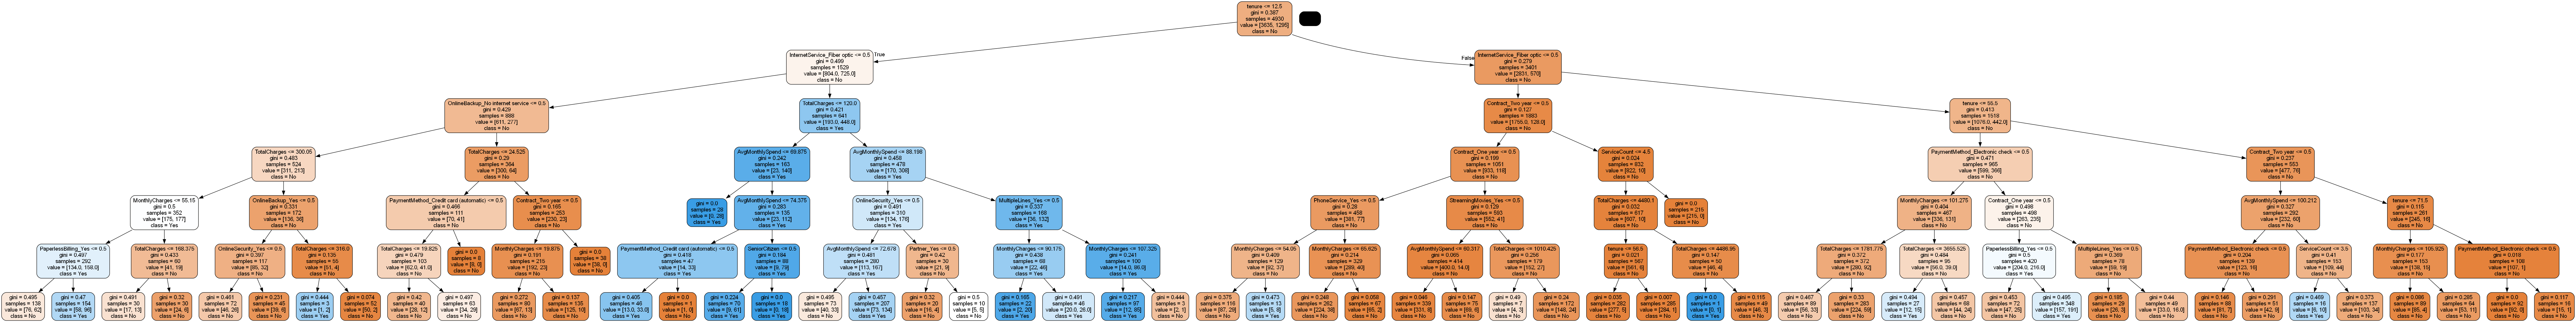

In [159]:
gph = get_dt_graph(dt2)
Image(gph.create_png())

#### Obseravtion

The decision tree model identifies which customer attributes most strongly influence churn. The feature importance bar chart shows:

SeniorCitizen → Older customers are more likely to churn.

InternetService_Fiber optic → Fiber optic users churn more than DSL users.

MonthlyCharges → Higher monthly bills increase churn risk.

ServiceCount → Customers with more services are less likely to churn.

Tenure → Short‑tenure customers remain vulnerable.

PaymentMethod_Electronic check → Linked to higher churn.

Other features (e.g., streaming services, gender, dependents) have lower importance.

#### Decision Tree Visualization & Path Tracing

The root node is Tenure, confirming it is a key predictor.

Short‑tenure customers branch toward churn risk, especially when combined with high monthly charges.

Long‑tenure customers branch toward retention, especially with multi‑year contracts.

Leaf nodes show the final prediction (churn vs. no churn) with counts of customers in each group.

#### Business Implication

Business Implications
Focus retention on senior citizens, with fiber optic service and high bills, and low tenure.

Offer loyalty discounts and contract upgrades to reduce churn.

Encourage automatic payments to stabilize retention.

Promote bundled services to increase engagement and retention.

## Save model and preprocessing pipeline

In [38]:
import joblib
joblib.dump(preprocessor, "../model/preprocessor.pkl")
joblib.dump(dt2, "../model/churn_model.pkl")

['../model/churn_model.pkl']